# California House Value Prediction — Model Comparison

This notebook compares three regression models on the California Housing dataset:

1. **Linear Regression** — simple linear baseline
2. **Random Forest Regressor** — ensemble of decision trees
3. **XGBoost Regressor** — gradient-boosted decision trees

The workflow uses a fixed `random_state`, a separate **training / validation / test** split, and evaluates all models using **MAE, RMSE, and R²**.

> **Important:** The target in the California Housing dataset is **median house value for a block group**, measured in units of $100,000. It is not the sale price of an individual house.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


## 2. Load the California Housing Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

# Rename the target to make its meaning explicit
df = df.rename(columns={"MedHouseVal": "median_house_value"})

print("Shape:", df.shape)
df.head()


Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Features

The dataset contains 8 input features:

- `MedInc` — median income
- `HouseAge` — median house age
- `AveRooms` — average number of rooms
- `AveBedrms` — average number of bedrooms
- `Population` — population
- `AveOccup` — average household occupancy
- `Latitude` — latitude
- `Longitude` — longitude

The target is `median_house_value`.


## 3. Basic Data Inspection

In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())


Dataset shape: (20640, 9)

Missing values:
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
median_house_value    0
dtype: int64

Data types:
MedInc                float64
HouseAge              float64
AveRooms              float64
AveBedrms             float64
Population            float64
AveOccup              float64
Latitude              float64
Longitude             float64
median_house_value    float64
dtype: object

Summary statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 4. Exploratory Data Analysis

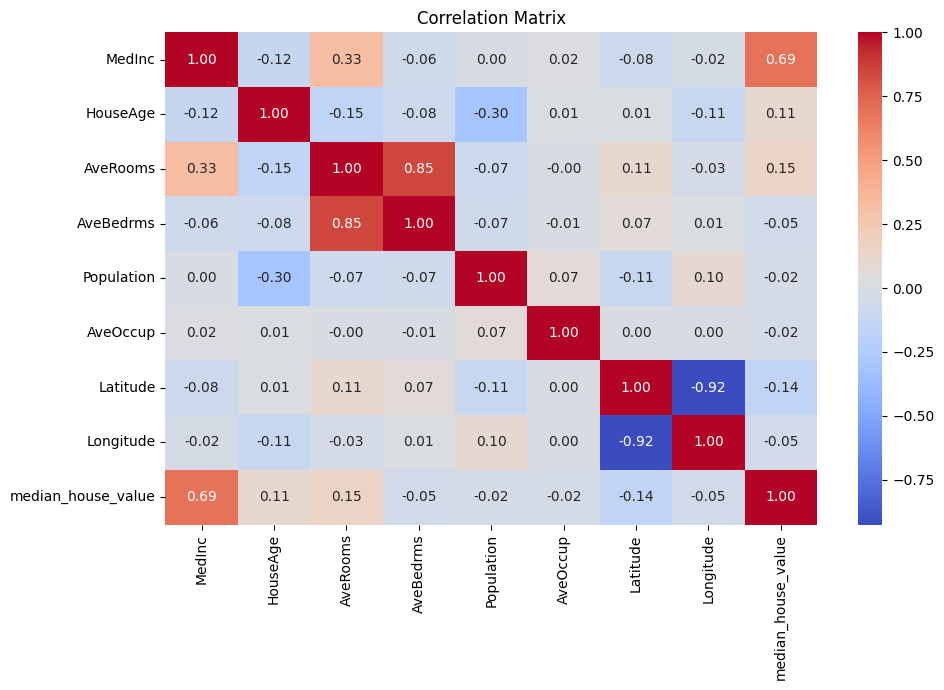

In [4]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


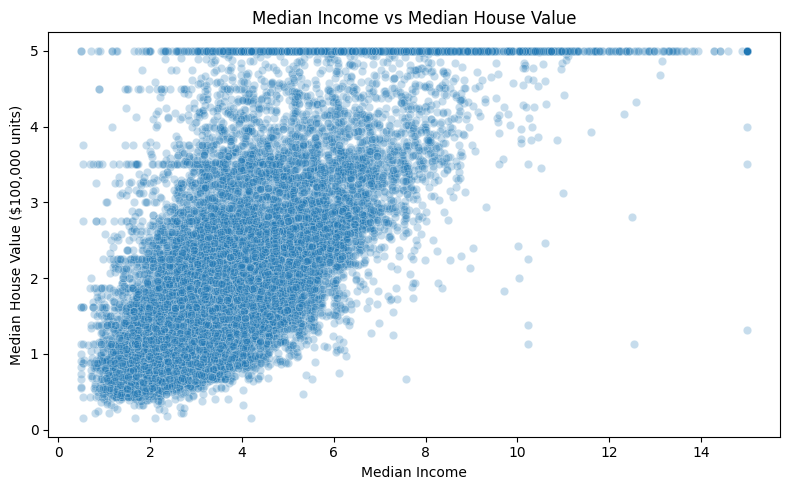

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="MedInc",
    y="median_house_value",
    alpha=0.25
)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100,000 units)")
plt.tight_layout()
plt.show()


## 5. Separate Features and Target

We separate:

- **X** → input features
- **y** → target variable


In [6]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 8)
y shape: (20640,)


## 6. Train / Validation / Test Split

We use:

- **70% training** — fit the models
- **15% validation** — compare/tune models
- **15% test** — final unbiased evaluation

The test set is kept untouched until the final comparison.

A fixed `random_state=42` makes the split reproducible.


In [7]:
# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# Second split: half of the temporary set for validation and half for test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print(f"Training set:   {X_train.shape[0]} samples ({len(X_train)/len(X):.0%})")
print(f"Validation set: {X_val.shape[0]} samples ({len(X_val)/len(X):.0%})")
print(f"Test set:       {X_test.shape[0]} samples ({len(X_test)/len(X):.0%})")


Training set:   14448 samples (70%)
Validation set: 3096 samples (15%)
Test set:       3096 samples (15%)


## 7. Evaluation Function

In [8]:
def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)

    mae = mean_absolute_error(y_data, predictions)
    rmse = np.sqrt(mean_squared_error(y_data, predictions))
    r2 = r2_score(y_data, predictions)

    return mae, rmse, r2


## 8. Model 1 — Linear Regression

In [9]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_val = evaluate_model(linear_model, X_val, y_val)

print("Linear Regression — Validation Results")
print(f"MAE  : {linear_val[0]:.4f}")
print(f"RMSE : {linear_val[1]:.4f}")
print(f"R²   : {linear_val[2]:.4f}")


Linear Regression — Validation Results
MAE  : 0.5335
RMSE : 0.7354
R²   : 0.5848


### Why Linear Regression?

Linear Regression assumes that the target can be approximated by a weighted combination of the input features:

\[
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_8x_8
\]

It provides a simple and interpretable baseline.


## 9. Model 2 — Random Forest

In [10]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_val = evaluate_model(random_forest, X_val, y_val)

print("Random Forest — Validation Results")
print(f"MAE  : {rf_val[0]:.4f}")
print(f"RMSE : {rf_val[1]:.4f}")
print(f"R²   : {rf_val[2]:.4f}")


Random Forest — Validation Results
MAE  : 0.3362
RMSE : 0.5148
R²   : 0.7966


### Why Random Forest?

Random Forest builds many decision trees using different bootstrap samples and random subsets of features.

The final prediction for regression is obtained by averaging the predictions of the individual trees.

It can capture nonlinear relationships and interactions without requiring feature scaling.


## 10. Model 3 — XGBoost

In [11]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_val = evaluate_model(xgb_model, X_val, y_val)

print("XGBoost — Validation Results")
print(f"MAE  : {xgb_val[0]:.4f}")
print(f"RMSE : {xgb_val[1]:.4f}")
print(f"R²   : {xgb_val[2]:.4f}")


XGBoost — Validation Results
MAE  : 0.2947
RMSE : 0.4534
R²   : 0.8422


### Why XGBoost?

XGBoost is a gradient-boosting algorithm.

Instead of building independent trees like Random Forest, it builds trees sequentially. Each new tree tries to reduce the errors made by the existing ensemble.

This allows it to model complex nonlinear relationships and feature interactions.


## 11. Compare Models on the Validation Set

In [12]:
validation_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [linear_val[0], rf_val[0], xgb_val[0]],
    "RMSE": [linear_val[1], rf_val[1], xgb_val[1]],
    "R2": [linear_val[2], rf_val[2], xgb_val[2]]
})

validation_results.sort_values("RMSE")


,Model,MAE,RMSE,R2
2,XGBoost,0.294717,0.453423,0.842188
1,Random Forest,0.336229,0.514777,0.796590
0,Linear Regression,0.533452,0.735442,0.584826


### How to interpret the validation results

- **MAE:** lower is better
- **RMSE:** lower is better
- **R²:** higher is better

We use the validation set to decide which model/configuration to take forward. We do **not** select the final model using the test set.


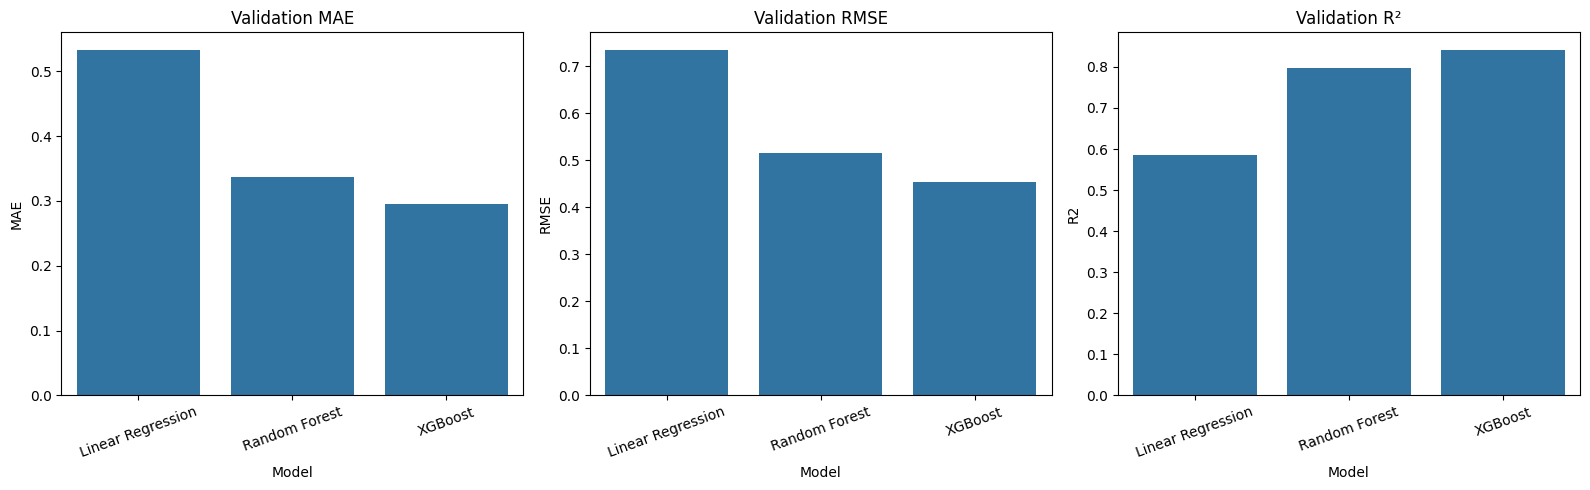

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=validation_results, x="Model", y="MAE", ax=axes[0])
axes[0].set_title("Validation MAE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=validation_results, x="Model", y="RMSE", ax=axes[1])
axes[1].set_title("Validation RMSE")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=validation_results, x="Model", y="R2", ax=axes[2])
axes[2].set_title("Validation R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 12. Select the Model Using the Validation Set

For this project, we select the model with the **lowest validation RMSE**.

The test set remains untouched until after this selection.


In [14]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest,
    "XGBoost": xgb_model
}

best_model_name = validation_results.loc[
    validation_results["RMSE"].idxmin(), "Model"
]

best_model = models[best_model_name]

print("Selected model based on validation RMSE:", best_model_name)


Selected model based on validation RMSE: XGBoost


## 13. Final Evaluation on the Test Set

Now that the model has been selected using validation data, we evaluate it once on the unseen test set.

This gives the final estimate of generalization performance.


In [15]:
test_results = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(model, X_test, y_test)
    test_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

test_results = pd.DataFrame(test_results)

test_results.sort_values("RMSE")


,Model,MAE,RMSE,R2
2,XGBoost,0.284849,0.430870,0.859602
1,Random Forest,0.322338,0.489087,0.819100
0,Linear Regression,0.521043,0.721291,0.606552


## 14. Actual vs Predicted Values for the Selected Model

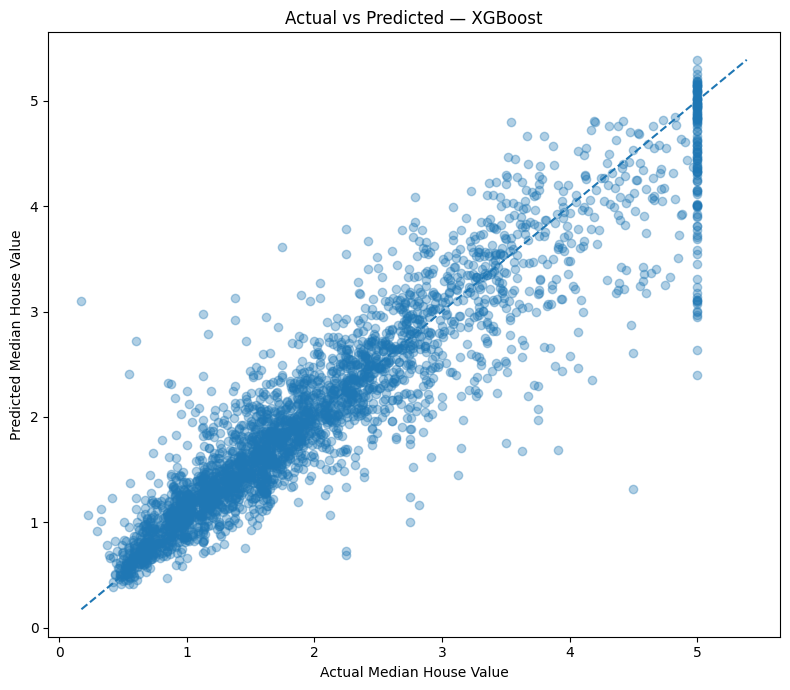

In [16]:
test_predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 7))
plt.scatter(y_test, test_predictions, alpha=0.35)

min_value = min(y_test.min(), test_predictions.min())
max_value = max(y_test.max(), test_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.show()


## 15. Feature Importance

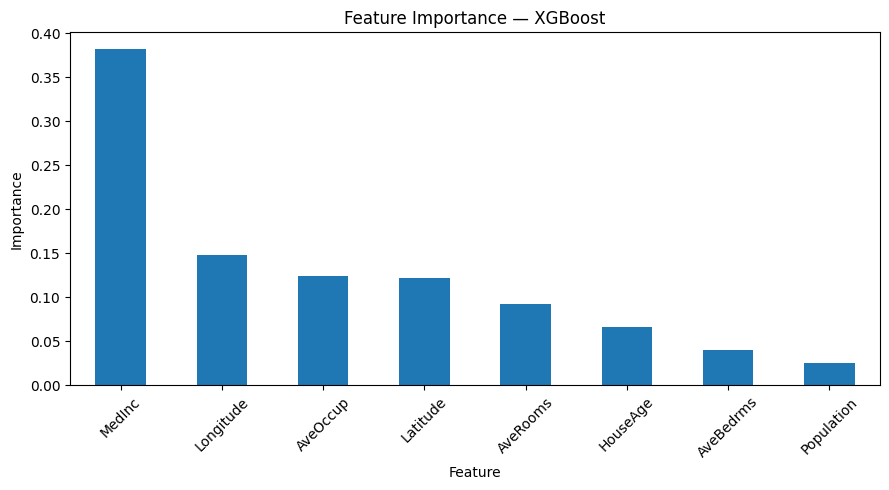

,importance
MedInc,0.381769
Longitude,0.148136
AveOccup,0.123896
Latitude,0.121990
AveRooms,0.092834
HouseAge,0.065815
AveBedrms,0.039992
Population,0.025569


In [17]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    importance.plot(kind="bar")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("importance"))
else:
    coefficients = pd.Series(
        best_model.coef_,
        index=X.columns
    ).sort_values(key=abs, ascending=False)

    display(coefficients.to_frame("coefficient"))


## 16. Final Conclusions

The project compares three progressively more flexible regression approaches:

**Linear Regression → Random Forest → XGBoost**

Linear Regression provides a simple baseline. Random Forest can model nonlinear relationships using an ensemble of decision trees. XGBoost uses sequential boosting to reduce prediction errors.

The final model is selected using the **validation set**, while the **test set is reserved for final evaluation**.

### Key evaluation metrics

- **MAE:** average absolute prediction error
- **RMSE:** gives more weight to large prediction errors
- **R²:** proportion of target variance explained relative to a mean baseline

### Important dataset note

The target represents **median house value of a California block group**, measured in $100,000 units. Therefore, this project is more precisely described as **California median house-value prediction** rather than prediction of an individual home's sale price.
